# Risk Transmission — Panel Data Visualisations

This notebook reads the existing CSV files from `Panel_A_Data` through `Panel_E_Data`. Related variables are combined in composite figures rather than plotted separately. Run the notebook from the project folder.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path('.')
COLORS = {'USDT': '#26A17B', 'USDC': '#2775CA', 'DAI': '#F5AC37', 'BTC': '#F7931A', 'ETH': '#627EEA'}
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False})

def read_time_csv(path, date_column='Date'):
    frame = pd.read_csv(path)
    frame[date_column] = pd.to_datetime(frame[date_column], errors='coerce', utc=True).dt.tz_localize(None)
    return frame.dropna(subset=[date_column]).sort_values(date_column)

def index_to_100(frame):
    result = frame.copy()
    for column in result.columns:
        valid = result[column].dropna()
        result[column] = result[column] / valid.iloc[0] * 100 if len(valid) else np.nan
    return result

def finish_figure(fig, title):
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)
    fig.tight_layout()
    plt.show()


Matplotlib is building the font cache; this may take a moment.


## Panel A — Stablecoin sector

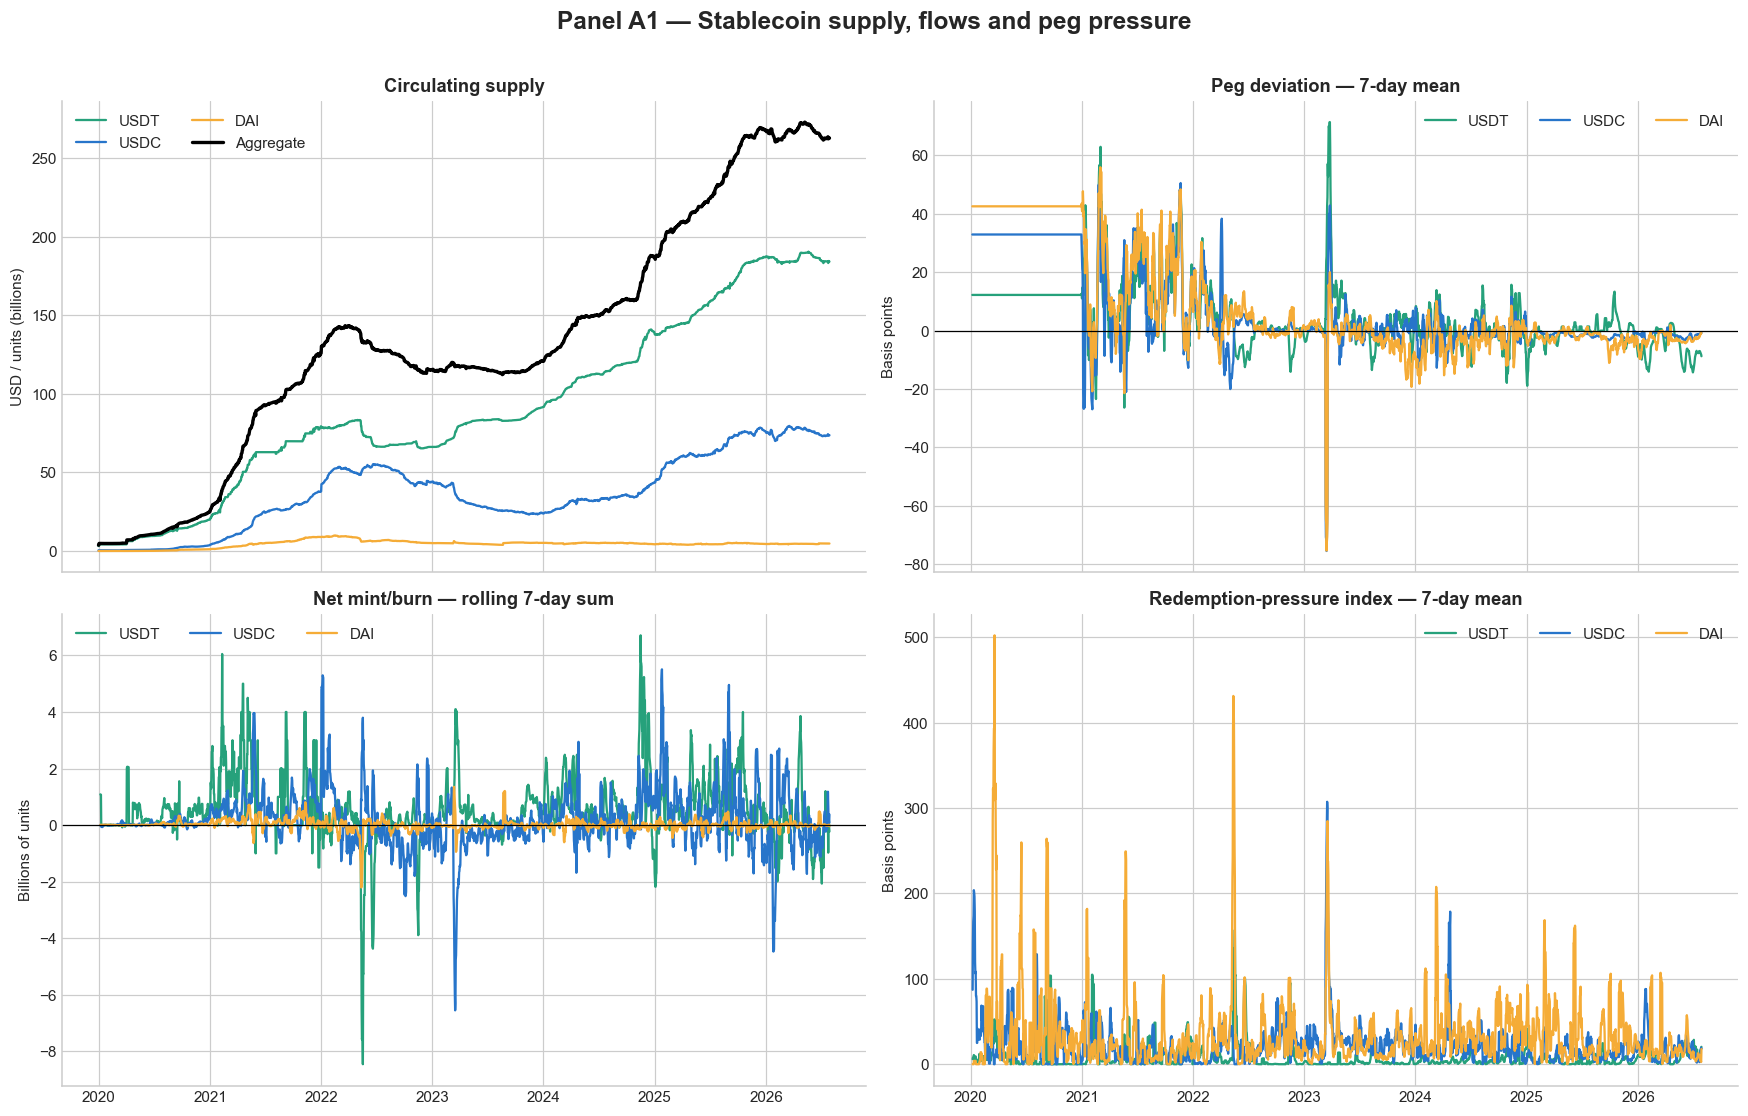

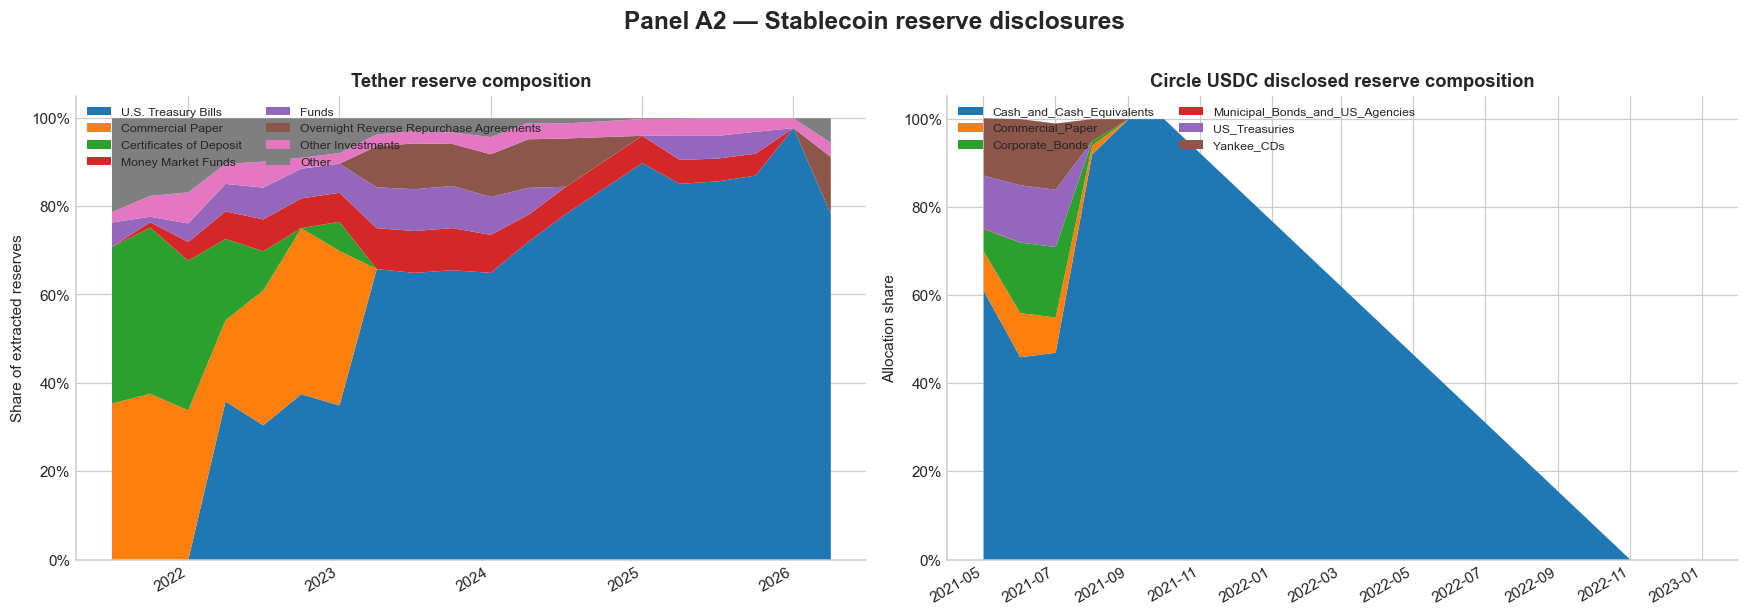

In [2]:
A = ROOT / 'Panel_A_Data'
supply = read_time_csv(A / 'Aggregate_Stablecoin_Supply_Daily.csv')
flows = read_time_csv(A / 'Net_Mint_Burn_USDT_USDC_DAI_Daily.csv')
pegs = read_time_csv(A / 'Secondary_Prices_and_Peg_Deviations_Daily.csv')
pressure = read_time_csv(A / 'Redemption_Pressure_Index_Daily.csv')

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
for coin in ['USDT', 'USDC', 'DAI']:
    axes[0, 0].plot(supply['Date'], supply[f'{coin}_Circulating_Supply'] / 1e9, label=coin, color=COLORS[coin])
axes[0, 0].plot(supply['Date'], supply['Aggregate_Stablecoin_Supply'] / 1e9, label='Aggregate', color='black', linewidth=2.2)
axes[0, 0].set(title='Circulating supply', ylabel='USD / units (billions)')
axes[0, 0].legend(ncol=2)

for coin in ['USDT', 'USDC', 'DAI']:
    axes[0, 1].plot(pegs['Date'], pegs[f'{coin}_Peg_Deviation_bps'].rolling(7).mean(), label=coin, color=COLORS[coin])
axes[0, 1].axhline(0, color='black', linewidth=0.8)
axes[0, 1].set(title='Peg deviation — 7-day mean', ylabel='Basis points')
axes[0, 1].legend(ncol=3)

for coin in ['USDT', 'USDC', 'DAI']:
    axes[1, 0].plot(flows['Date'], flows[f'{coin}_Net_Mint_Burn_Units'].rolling(7).sum() / 1e9, label=coin, color=COLORS[coin])
axes[1, 0].axhline(0, color='black', linewidth=0.8)
axes[1, 0].set(title='Net mint/burn — rolling 7-day sum', ylabel='Billions of units')
axes[1, 0].legend(ncol=3)

for coin in ['USDT', 'USDC', 'DAI']:
    axes[1, 1].plot(pressure['Date'], pressure[f'{coin}_Redemption_Pressure_Index_bps'].rolling(7).mean(), label=coin, color=COLORS[coin])
axes[1, 1].set(title='Redemption-pressure index — 7-day mean', ylabel='Basis points')
axes[1, 1].legend(ncol=3)
finish_figure(fig, 'Panel A1 — Stablecoin supply, flows and peg pressure')

tether = read_time_csv(A / 'Tether_Reserve_Composition_Quarterly.csv', 'Report_Date')
circle = read_time_csv(A / 'Circle_USDC_Monthly_Reserve_Composition_From_May_2021.csv', 'Report_Month')
circle = circle[~circle['Reserve_Category'].isin(['Total_Reserves', 'USDC_in_Circulation'])].copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
tether_pivot = tether.pivot_table(index='Report_Date', columns='Asset_Category', values='Share_of_Extracted_Reserves', aggfunc='sum').fillna(0)
tether_top = tether_pivot.mean().nlargest(7).index
tether_plot = tether_pivot[tether_top].copy()
tether_plot['Other'] = tether_pivot.drop(columns=tether_top).sum(axis=1)
tether_plot.plot.area(ax=axes[0], linewidth=0)
axes[0].set(title='Tether reserve composition', ylabel='Share of extracted reserves', xlabel='')
axes[0].yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
axes[0].legend(loc='upper left', fontsize=8, ncol=2)
circle_pivot = circle.pivot_table(index='Report_Month', columns='Reserve_Category', values='Allocation_Share', aggfunc='sum').fillna(0)
circle_pivot.plot.area(ax=axes[1], linewidth=0)
axes[1].set(title='Circle USDC disclosed reserve composition', ylabel='Allocation share', xlabel='')
axes[1].yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
finish_figure(fig, 'Panel A2 — Stablecoin reserve disclosures')


## Panel B — Core funding and money markets

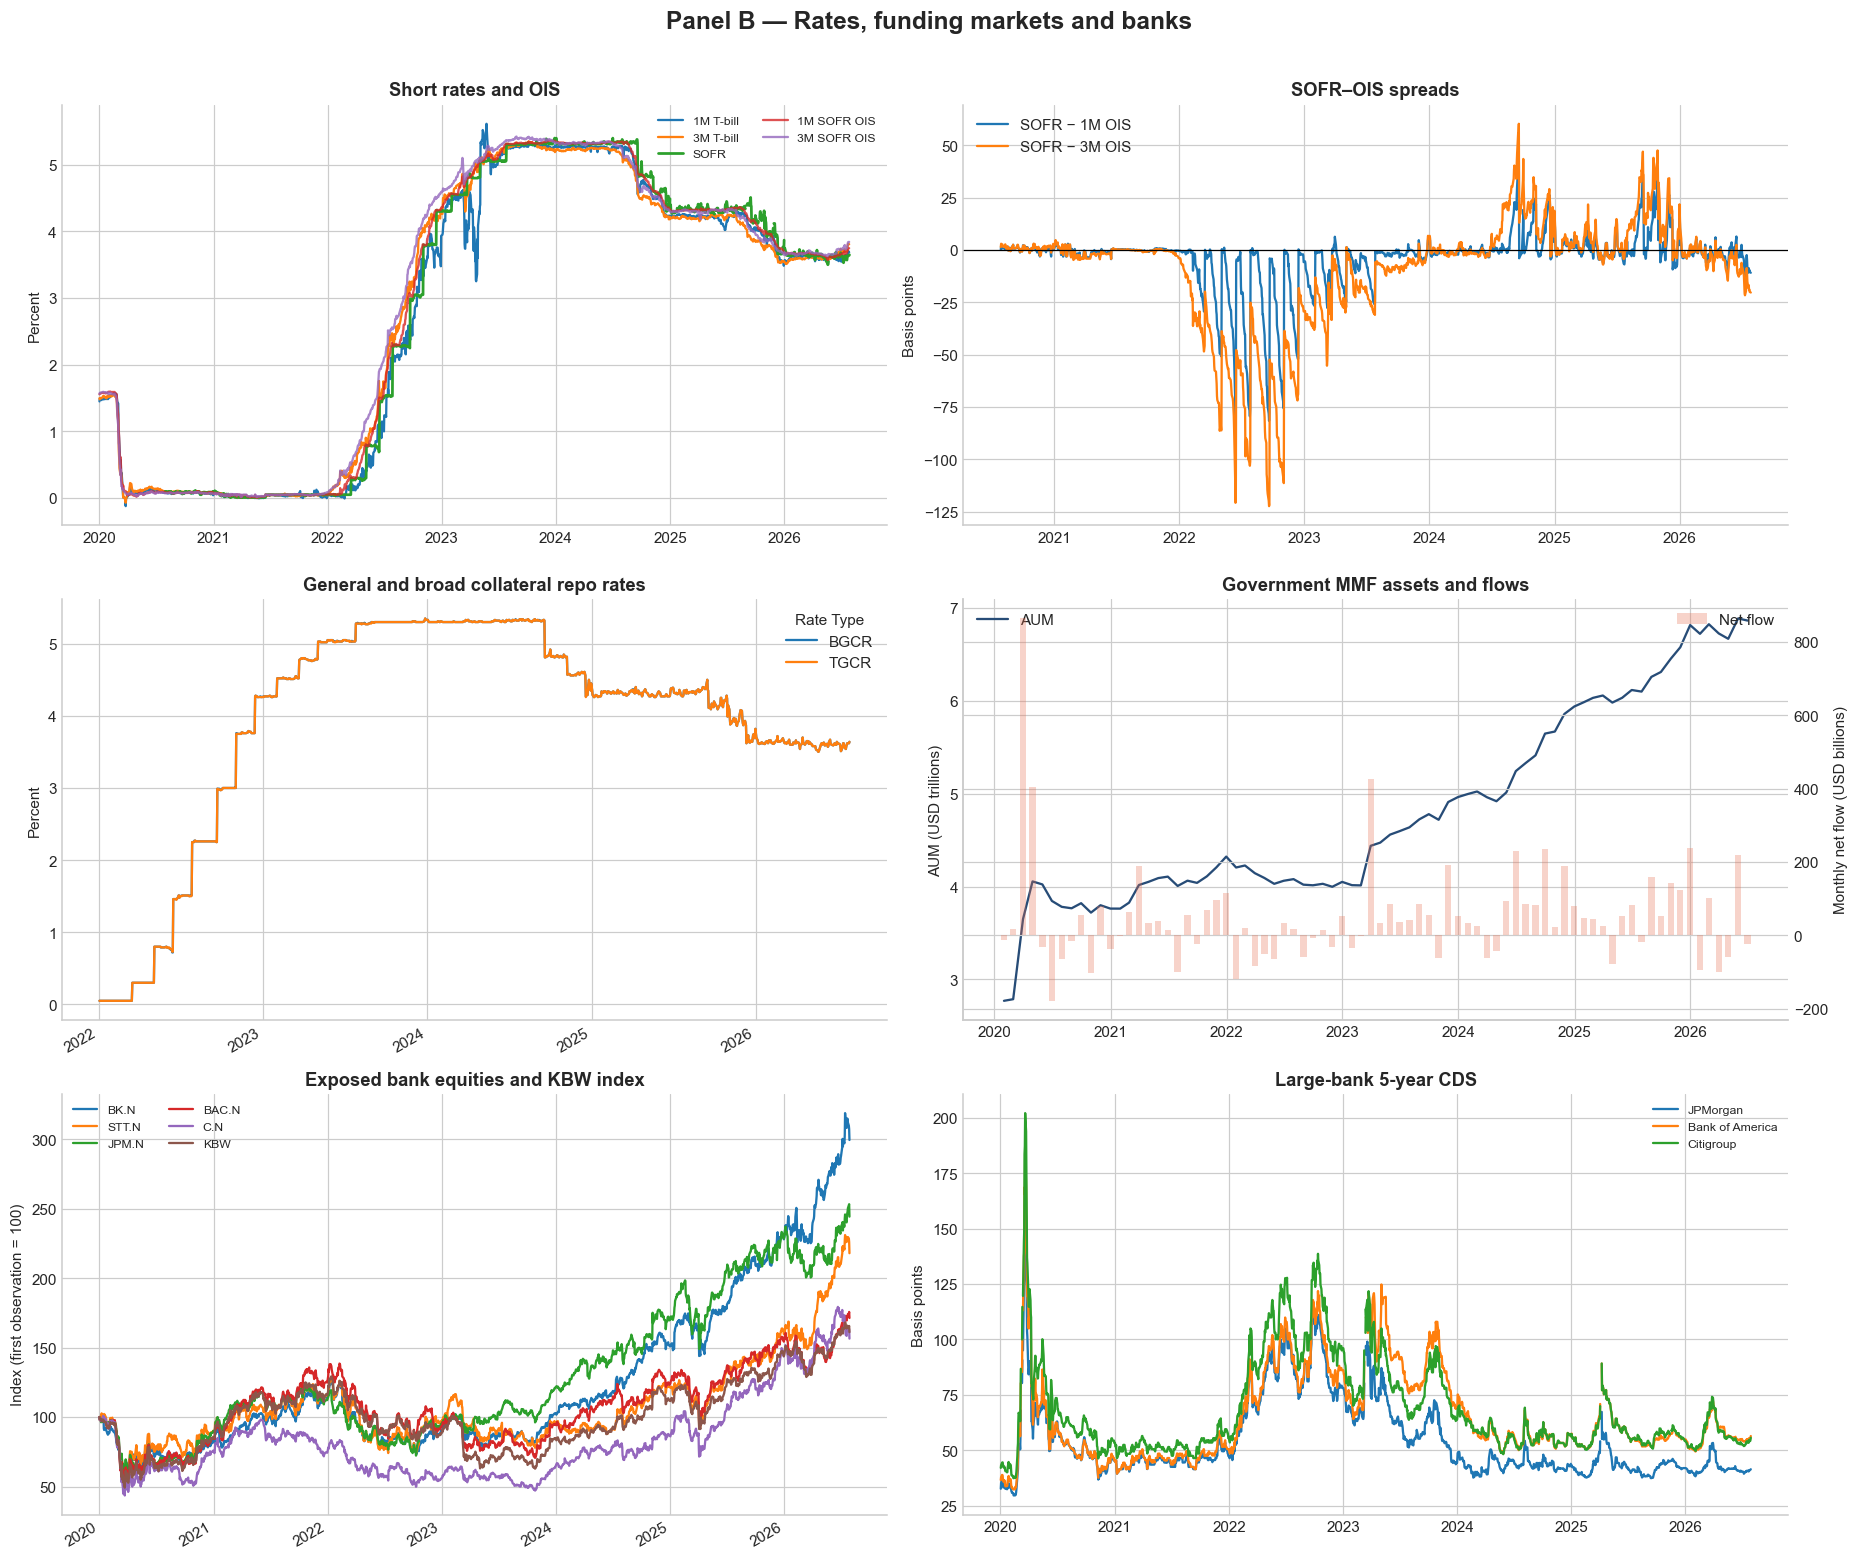

In [3]:
B = ROOT / 'Panel_B_Data'
tb1 = read_time_csv(B / 'US_1M_Treasury_Bill_Yield.csv')
tb3 = read_time_csv(B / 'US_3M_Treasury_Bill_Yield.csv')
ois1 = read_time_csv(B / 'USD_1M_SOFR_OIS.csv')
ois3 = read_time_csv(B / 'USD_3M_SOFR_OIS.csv')
sofr = read_time_csv(B / 'SOFR.csv', 'observation_date')
spreads = read_time_csv(B / 'SOFR_OIS_Spreads_Daily.csv')
repo = read_time_csv(B / 'TGCR_BGCR.csv', 'Effective Date')
aum = read_time_csv(B / 'Government_MMF_Total_AUM_Monthly.csv')
mmf_flow = read_time_csv(B / 'Government_MMF_Net_Flows_Monthly.csv')
equities = read_time_csv(B / 'Exposed_Custodial_Bank_Equities_Daily.csv').set_index('Date')
kbw = read_time_csv(B / 'KBW_Bank_Index_Daily.csv').set_index('Date').rename(columns={'TRDPRC_1': 'KBW'})
cds = read_time_csv(B / 'Bank_5Y_CDS_Daily.csv')

fig, axes = plt.subplots(3, 2, figsize=(17, 14))
axes[0, 0].plot(tb1['Date'], tb1['US_1M_Treasury_Bill_Yield'], label='1M T-bill')
axes[0, 0].plot(tb3['Date'], tb3['US_3M_Treasury_Bill_Yield'], label='3M T-bill')
axes[0, 0].plot(sofr['observation_date'], sofr['SOFR'], label='SOFR', linewidth=1.8)
axes[0, 0].plot(ois1['Date'], ois1['USD_1M_SOFR_OIS'], label='1M SOFR OIS', alpha=.8)
axes[0, 0].plot(ois3['Date'], ois3['USD_3M_SOFR_OIS'], label='3M SOFR OIS', alpha=.8)
axes[0, 0].set(title='Short rates and OIS', ylabel='Percent')
axes[0, 0].legend(ncol=2, fontsize=8)

axes[0, 1].plot(spreads['Date'], spreads['SOFR_minus_1M_OIS_bps'], label='SOFR − 1M OIS')
axes[0, 1].plot(spreads['Date'], spreads['SOFR_minus_3M_OIS_bps'], label='SOFR − 3M OIS')
axes[0, 1].axhline(0, color='black', linewidth=.8)
axes[0, 1].set(title='SOFR–OIS spreads', ylabel='Basis points')
axes[0, 1].legend()

repo_pivot = repo.pivot_table(index='Effective Date', columns='Rate Type', values='Rate (%)', aggfunc='last')
repo_pivot.plot(ax=axes[1, 0])
axes[1, 0].set(title='General and broad collateral repo rates', ylabel='Percent', xlabel='')

axes[1, 1].plot(aum['Date'], aum['Government_MMF_Total_AUM_USD'] / 1e12, color='#274C77', label='AUM')
ax_flow = axes[1, 1].twinx()
ax_flow.bar(mmf_flow['Date'], mmf_flow['Government_MMF_Net_Flow_USD'] / 1e9, width=20, alpha=.3, color='#E76F51', label='Net flow')
axes[1, 1].set(title='Government MMF assets and flows', ylabel='AUM (USD trillions)')
ax_flow.set_ylabel('Monthly net flow (USD billions)')
axes[1, 1].legend(loc='upper left'); ax_flow.legend(loc='upper right')

bank_prices = pd.concat([equities, kbw], axis=1).sort_index()
index_to_100(bank_prices).plot(ax=axes[2, 0])
axes[2, 0].set(title='Exposed bank equities and KBW index', ylabel='Index (first observation = 100)', xlabel='')
axes[2, 0].legend(ncol=2, fontsize=8)

cds_columns = ['JPMorgan_5Y_CDS_bps', 'Bank_of_America_5Y_CDS_bps', 'Citigroup_5Y_CDS_bps']
for column in cds_columns:
    axes[2, 1].plot(cds['Date'], cds[column], label=column.replace('_5Y_CDS_bps', '').replace('_', ' '))
axes[2, 1].set(title='Large-bank 5-year CDS', ylabel='Basis points')
axes[2, 1].legend(fontsize=8)
finish_figure(fig, 'Panel B — Rates, funding markets and banks')


## Panel C — Crypto and tokenization

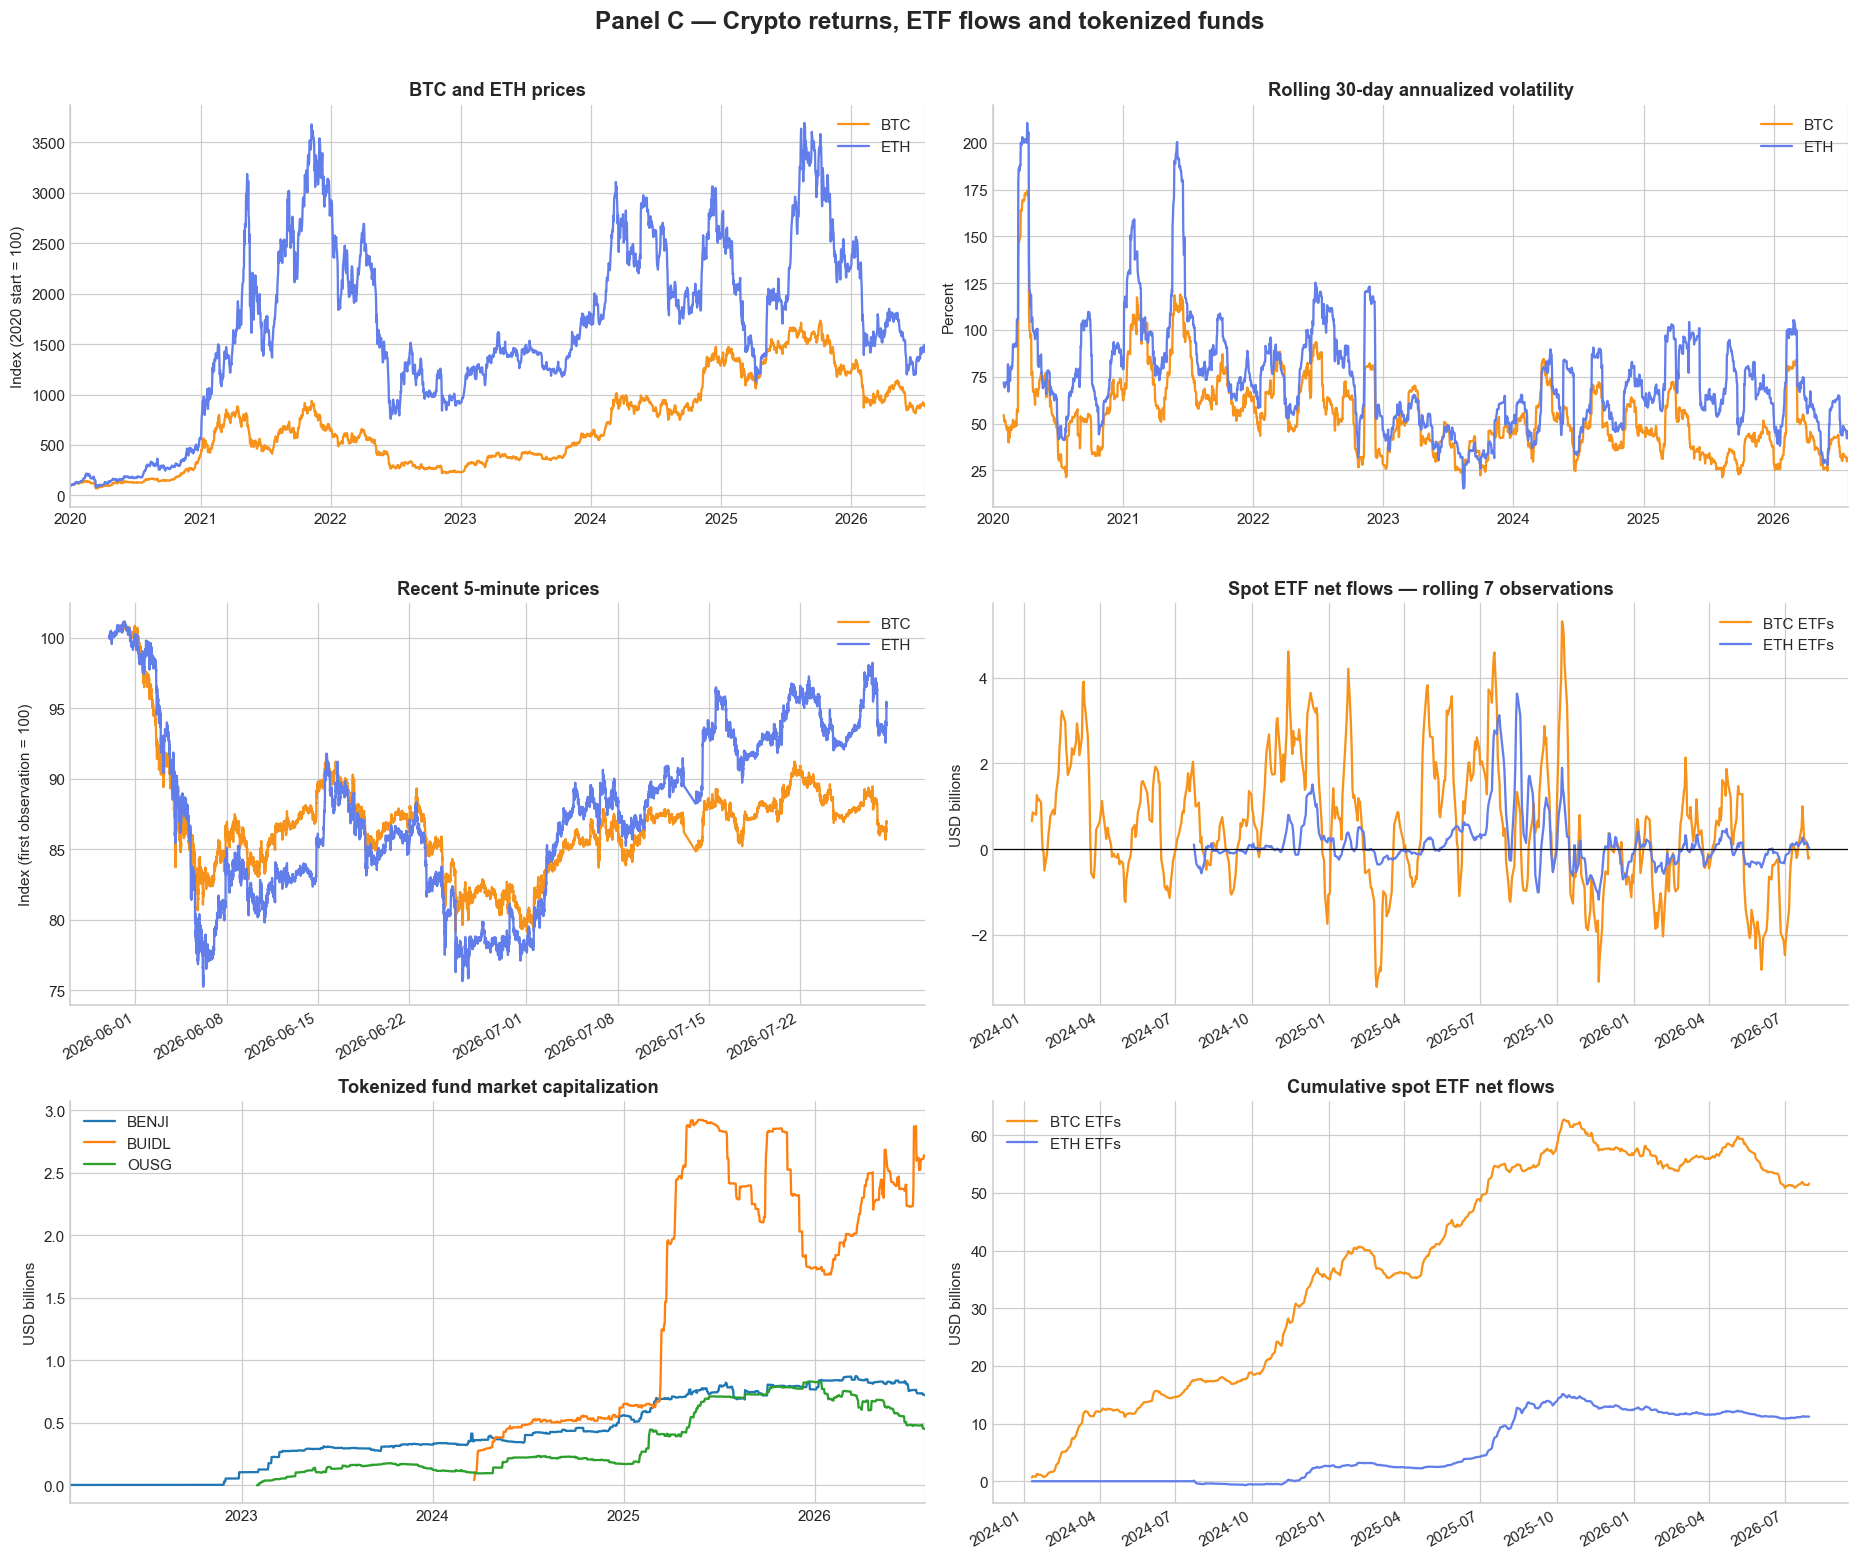

In [4]:
C = ROOT / 'Panel_C_Data'
btc = read_time_csv(C / 'BTC_Daily_Returns.csv')
eth = read_time_csv(C / 'ETH_Daily_Returns.csv')
btc5 = read_time_csv(C / 'BTC_5_Minute_Prices.csv', 'Datetime_UTC')
eth5 = read_time_csv(C / 'ETH_5_Minute_Prices.csv', 'Datetime_UTC')
btc_etf = read_time_csv(C / 'Spot_BTC_ETF_Net_Flows_Daily.csv')
eth_etf = read_time_csv(C / 'Spot_ETH_ETF_Net_Flows_Daily.csv')

fig, axes = plt.subplots(3, 2, figsize=(17, 14))
daily_prices = pd.DataFrame({'BTC': btc.set_index('Date')['BTC_Adjusted_Close_USD'], 'ETH': eth.set_index('Date')['ETH_Adjusted_Close_USD']})
index_to_100(daily_prices).plot(ax=axes[0, 0], color=[COLORS['BTC'], COLORS['ETH']])
axes[0, 0].set(title='BTC and ETH prices', ylabel='Index (2020 start = 100)', xlabel='')

annualized_vol = pd.DataFrame({'BTC': btc.set_index('Date')['BTC_Daily_Return'].rolling(30).std() * np.sqrt(365) * 100, 'ETH': eth.set_index('Date')['ETH_Daily_Return'].rolling(30).std() * np.sqrt(365) * 100})
annualized_vol.plot(ax=axes[0, 1], color=[COLORS['BTC'], COLORS['ETH']])
axes[0, 1].set(title='Rolling 30-day annualized volatility', ylabel='Percent', xlabel='')

intraday = pd.DataFrame({'BTC': btc5.set_index('Datetime_UTC')['Close'], 'ETH': eth5.set_index('Datetime_UTC')['Close']}).dropna(how='all')
index_to_100(intraday).plot(ax=axes[1, 0], color=[COLORS['BTC'], COLORS['ETH']])
axes[1, 0].set(title='Recent 5-minute prices', ylabel='Index (first observation = 100)', xlabel='')

etf_flows = pd.concat([btc_etf.set_index('Date')['Total_Net_Flow_USD'].rename('BTC ETFs'), eth_etf.set_index('Date')['Total_Net_Flow_USD'].rename('ETH ETFs')], axis=1).sort_index()
(etf_flows.rolling(7, min_periods=1).sum() / 1e9).plot(ax=axes[1, 1], color=[COLORS['BTC'], COLORS['ETH']])
axes[1, 1].axhline(0, color='black', linewidth=.8)
axes[1, 1].set(title='Spot ETF net flows — rolling 7 observations', ylabel='USD billions', xlabel='')

fund_totals = {}
for fund in ['BENJI', 'BUIDL', 'OUSG']:
    frame = read_time_csv(C / f'{fund}_Market_cap.csv')
    chain_columns = [c for c in frame.columns if c not in ['Timestamp', 'Date', 'Measure']]
    fund_totals[fund] = frame.set_index('Date')[chain_columns].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
tokenized = pd.concat(fund_totals, axis=1).sort_index() / 1e9
tokenized.plot(ax=axes[2, 0])
axes[2, 0].set(title='Tokenized fund market capitalization', ylabel='USD billions', xlabel='')

cumulative_etf = etf_flows.fillna(0).cumsum() / 1e9
cumulative_etf.plot(ax=axes[2, 1], color=[COLORS['BTC'], COLORS['ETH']])
axes[2, 1].set(title='Cumulative spot ETF net flows', ylabel='USD billions', xlabel='')
finish_figure(fig, 'Panel C — Crypto returns, ETF flows and tokenized funds')


## Panel D — State variables and stress regimes

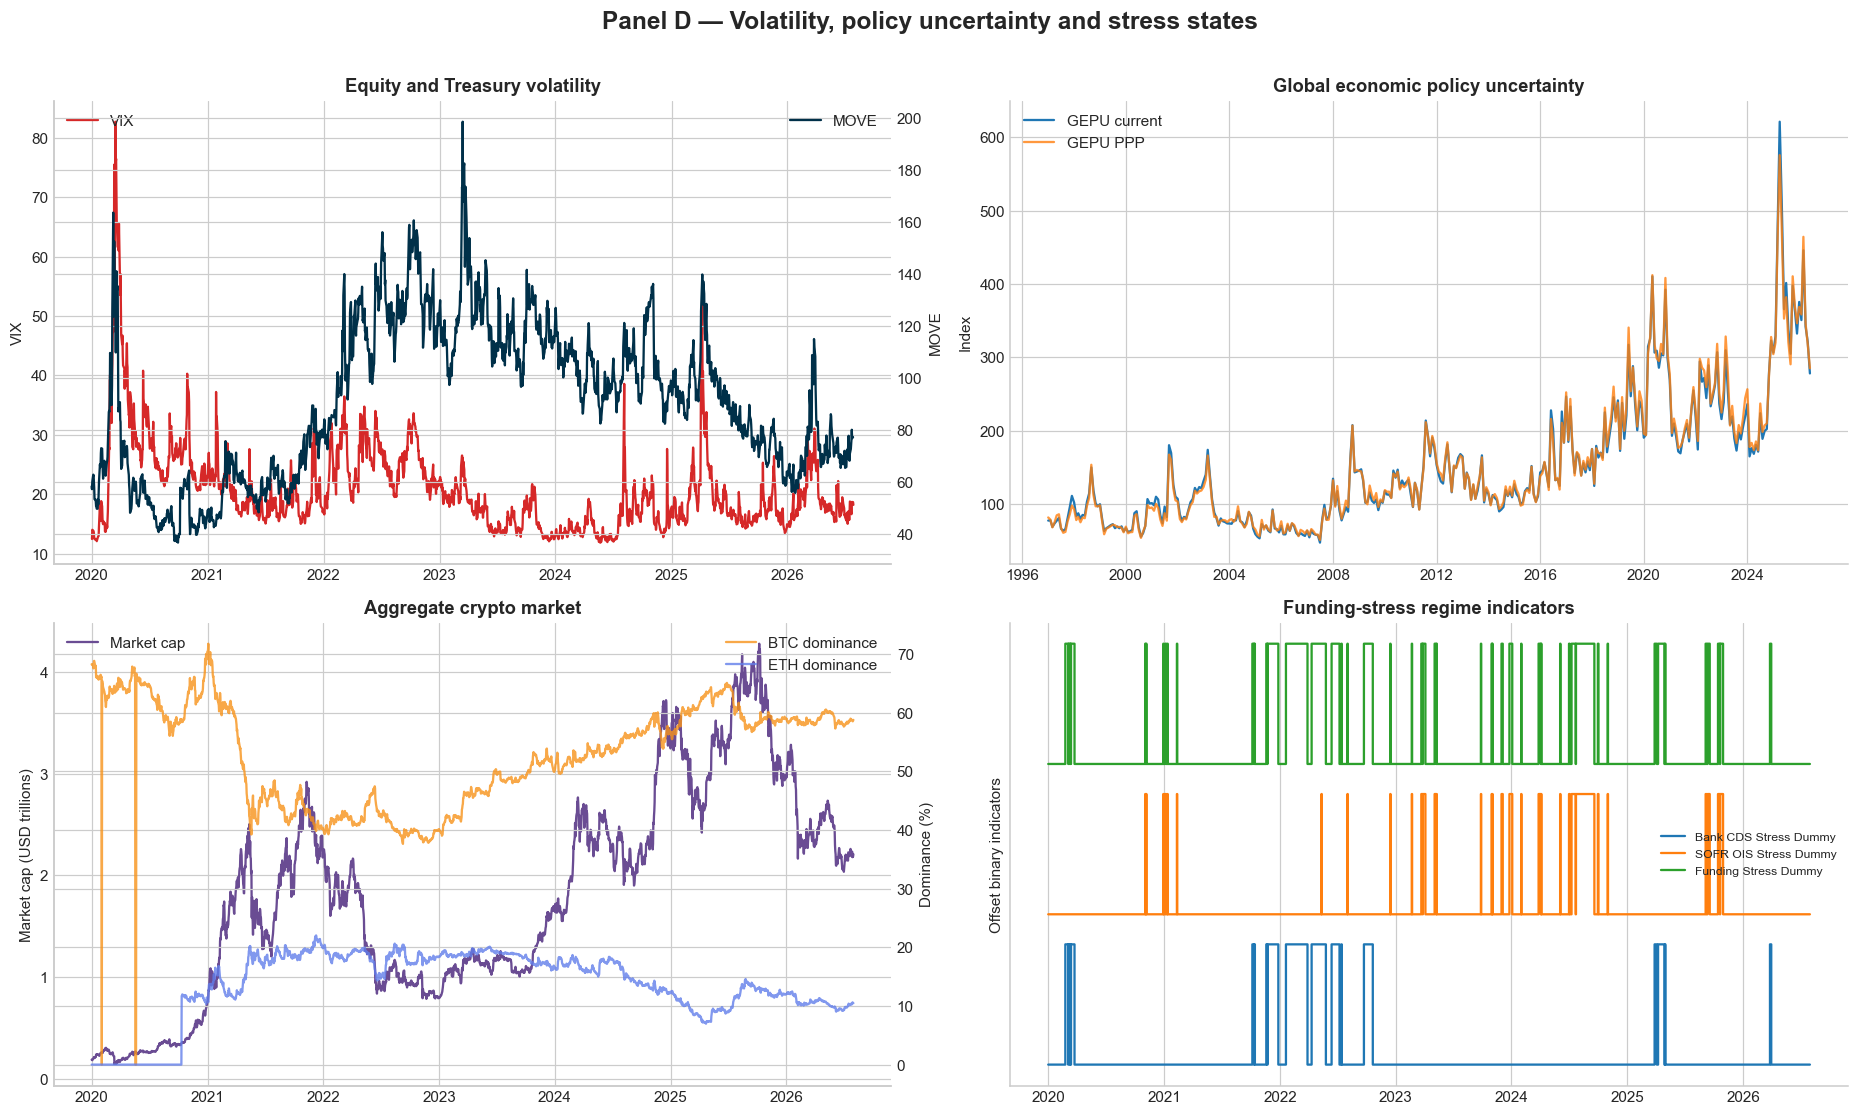

In [5]:
D = ROOT / 'Panel_D_Data'
vix = read_time_csv(D / 'VIX_Index_Daily.csv')
move = read_time_csv(D / 'MOVE_Index_Daily.csv')
crypto_cap = read_time_csv(D / 'Aggregate_Crypto_Market_Cap_Daily.csv')
stress = read_time_csv(D / 'Funding_Stress_Dummies_Daily.csv')
gepu = pd.read_csv(D / 'Global_Policy_Uncertainty_Data.csv')
gepu['Date'] = pd.to_datetime(dict(year=gepu['Year'], month=gepu['Month'], day=1), errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
ax_move = axes[0, 0].twinx()
axes[0, 0].plot(vix['Date'], vix['Close'], label='VIX', color='#D62828')
ax_move.plot(move['Date'], move['MOVE_Index'], label='MOVE', color='#003049')
axes[0, 0].set(title='Equity and Treasury volatility', ylabel='VIX')
ax_move.set_ylabel('MOVE')
axes[0, 0].legend(loc='upper left'); ax_move.legend(loc='upper right')

axes[0, 1].plot(gepu['Date'], gepu['GEPU_current'], label='GEPU current')
axes[0, 1].plot(gepu['Date'], gepu['GEPU_ppp'], label='GEPU PPP', alpha=.8)
axes[0, 1].set(title='Global economic policy uncertainty', ylabel='Index')
axes[0, 1].legend()

axes[1, 0].plot(crypto_cap['Date'], crypto_cap['Aggregate_Crypto_Market_Cap_USD'] / 1e12, label='Market cap', color='#6A4C93')
ax_dom = axes[1, 0].twinx()
ax_dom.plot(crypto_cap['Date'], crypto_cap['BTC_Dominance_Percent'], label='BTC dominance', color=COLORS['BTC'], alpha=.8)
ax_dom.plot(crypto_cap['Date'], crypto_cap['ETH_Dominance_Percent'], label='ETH dominance', color=COLORS['ETH'], alpha=.8)
axes[1, 0].set(title='Aggregate crypto market', ylabel='Market cap (USD trillions)')
ax_dom.set_ylabel('Dominance (%)')
axes[1, 0].legend(loc='upper left'); ax_dom.legend(loc='upper right')

dummy_cols = ['Bank_CDS_Stress_Dummy', 'SOFR_OIS_Stress_Dummy', 'Funding_Stress_Dummy']
for i, column in enumerate(dummy_cols):
    axes[1, 1].step(stress['Date'], stress[column] + i * 1.25, where='post', label=column.replace('_', ' '))
axes[1, 1].set(title='Funding-stress regime indicators', ylabel='Offset binary indicators', yticks=[])
axes[1, 1].legend(fontsize=8)
finish_figure(fig, 'Panel D — Volatility, policy uncertainty and stress states')


## Panel E — Placebo / falsification assets

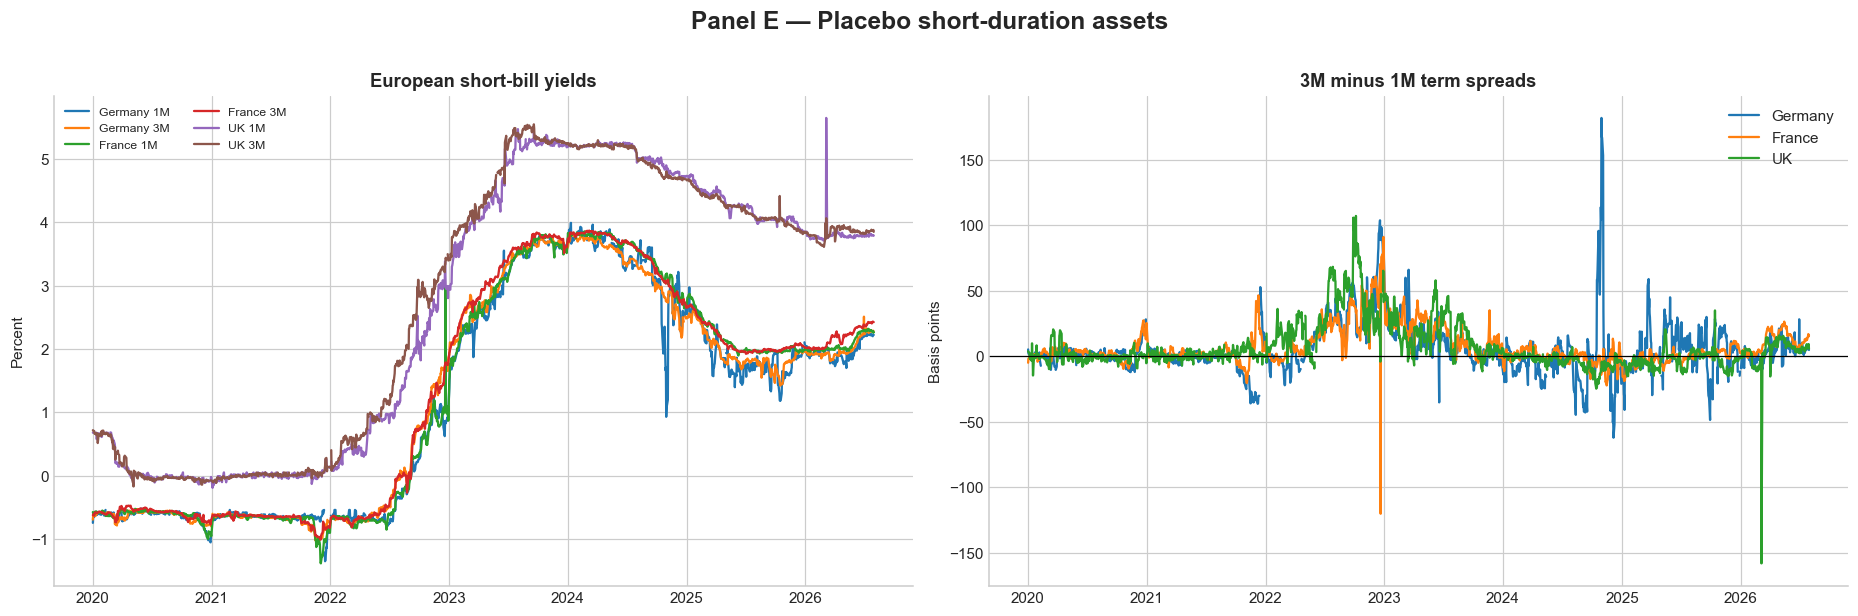

In [6]:
E = ROOT / 'Panel_E_Data'
placebo = read_time_csv(E / 'Placebo_Short_Duration_Assets_Daily.csv')
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), sharex=True)
yield_columns = [column for column in placebo.columns if column != 'Date']
for column in yield_columns:
    axes[0].plot(placebo['Date'], placebo[column], label=column.replace('_Bill_Yield', '').replace('_', ' '))
axes[0].set(title='European short-bill yields', ylabel='Percent')
axes[0].legend(ncol=2, fontsize=8)
for country in ['Germany', 'France', 'UK']:
    spread = (placebo[f'{country}_3M_Bill_Yield'] - placebo[f'{country}_1M_Bill_Yield']) * 100
    axes[1].plot(placebo['Date'], spread, label=country)
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].set(title='3M minus 1M term spreads', ylabel='Basis points')
axes[1].legend()
finish_figure(fig, 'Panel E — Placebo short-duration assets')


### Coverage note

The figures use the cleaned analytical CSVs. Metadata-only files such as `Bank_5Y_CDS_Availability.csv`, the one-column `MMF_by_cata.csv`, coverage flags, and raw LSEG extraction files are not charted because they duplicate plotted data or do not contain a numerical time series.